<a href="https://www.kaggle.com/code/sonawanelalitsunil/foodpanda-dataset-analysis-2025-ml?scriptVersionId=260274075" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/foodpanda-analysis-dataset-2025/Foodpanda Analysis Dataset.csv


## Title:
📊 Foodpanda Dataset Analysis 2025

## Description:
The Foodpanda Analysis Dataset 2025 provides insights into online food delivery patterns, customer behavior, and business performance metrics for the year 2025. This dataset can include details such as restaurant information, food categories, order frequency, delivery times, customer demographics, ratings, payment methods, and overall satisfaction levels. By analyzing this data, one can uncover trends in consumer preferences, evaluate peak ordering hours, identify top-performing restaurants or cuisines, and measure the impact of delivery efficiency on customer loyalty. It serves as a valuable resource for data analysis, machine learning, and business intelligence tasks, enabling stakeholders to make data-driven decisions in the online food delivery ecosystem.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/foodpanda-analysis-dataset-2025/Foodpanda Analysis Dataset.csv")

In [3]:
df.head()

,customer_id,gender,age,city,signup_date,order_id,order_date,restaurant_name,dish_name,category,quantity,price,payment_method,order_frequency,last_order_date,loyalty_points,churned,rating,rating_date,delivery_status
0,C5663,Male,Adult,Peshawar,1/14/2024,O9663,8/23/2023,McDonald's,Burger,Italian,5,1478.27,Cash,38,7/19/2025,238,Active,3,10/14/2024,Cancelled
1,C2831,Male,Adult,Multan,7/7/2024,O6831,8/23/2023,KFC,Burger,Italian,3,956.04,Wallet,24,11/25/2024,81,Active,2,8/21/2025,Delayed
2,C2851,Other,Senior,Multan,6/20/2025,O6851,8/23/2023,Pizza Hut,Fries,Italian,2,882.51,Cash,42,5/10/2025,82,Inactive,3,9/19/2024,Delayed
3,C1694,Female,Senior,Peshawar,9/5/2023,O5694,8/23/2023,Subway,Pizza,Dessert,4,231.30,Card,27,7/24/2025,45,Inactive,2,6/29/2025,Delayed
4,C4339,Other,Senior,Lahore,12/29/2023,O8339,8/24/2023,KFC,Sandwich,Dessert,1,1156.69,Cash,35,12/21/2024,418,Inactive,3,3/6/2025,Cancelled


In [4]:
df.tail()

,customer_id,gender,age,city,signup_date,order_id,order_date,restaurant_name,dish_name,category,quantity,price,payment_method,order_frequency,last_order_date,loyalty_points,churned,rating,rating_date,delivery_status
5995,C6849,Male,Adult,Multan,11/25/2024,O10849,8/22/2025,Pizza Hut,Burger,Italian,4,875.71,Cash,28,11/29/2024,166,Active,5,12/30/2024,Cancelled
5996,C3787,Female,Adult,Islamabad,1/28/2025,O7787,8/22/2025,KFC,Pizza,Italian,5,1118.26,Cash,12,6/8/2025,193,Inactive,3,2/9/2025,Delayed
5997,C2841,Other,Teenager,Islamabad,10/19/2023,O6841,8/22/2025,KFC,Sandwich,Italian,4,1005.83,Card,31,12/30/2024,278,Active,4,3/23/2025,Cancelled
5998,C1624,Male,Adult,Islamabad,6/17/2024,O5624,8/22/2025,KFC,Fries,Fast Food,4,1226.10,Card,37,12/27/2024,55,Inactive,2,3/15/2025,Delivered
5999,C2068,Female,Adult,Multan,3/15/2025,O6068,8/22/2025,Burger King,Fries,Fast Food,3,1131.27,Card,2,6/13/2025,41,Inactive,1,7/15/2025,Delayed


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      6000 non-null   object 
 1   gender           6000 non-null   object 
 2   age              6000 non-null   object 
 3   city             6000 non-null   object 
 4   signup_date      6000 non-null   object 
 5   order_id         6000 non-null   object 
 6   order_date       6000 non-null   object 
 7   restaurant_name  6000 non-null   object 
 8   dish_name        6000 non-null   object 
 9   category         6000 non-null   object 
 10  quantity         6000 non-null   int64  
 11  price            6000 non-null   float64
 12  payment_method   6000 non-null   object 
 13  order_frequency  6000 non-null   int64  
 14  last_order_date  6000 non-null   object 
 15  loyalty_points   6000 non-null   int64  
 16  churned          6000 non-null   object 
 17  rating        

In [6]:
df.describe()

,quantity,price,order_frequency,loyalty_points,rating
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,2.991667,800.524880,25.304667,250.173667,2.996833
std,1.414778,404.855029,14.358930,144.608478,1.406113
min,1.000000,100.300000,1.000000,0.000000,1.000000
25%,2.000000,441.997500,13.000000,125.000000,2.000000
50%,3.000000,806.460000,25.000000,249.500000,3.000000
75%,4.000000,1149.737500,37.000000,378.000000,4.000000
max,5.000000,1499.950000,50.000000,500.000000,5.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      6000 non-null   object 
 1   gender           6000 non-null   object 
 2   age              6000 non-null   object 
 3   city             6000 non-null   object 
 4   signup_date      6000 non-null   object 
 5   order_id         6000 non-null   object 
 6   order_date       6000 non-null   object 
 7   restaurant_name  6000 non-null   object 
 8   dish_name        6000 non-null   object 
 9   category         6000 non-null   object 
 10  quantity         6000 non-null   int64  
 11  price            6000 non-null   float64
 12  payment_method   6000 non-null   object 
 13  order_frequency  6000 non-null   int64  
 14  last_order_date  6000 non-null   object 
 15  loyalty_points   6000 non-null   int64  
 16  churned          6000 non-null   object 
 17  rating        

In [8]:
df.isnull().sum()

customer_id        0
gender             0
age                0
city               0
signup_date        0
order_id           0
order_date         0
restaurant_name    0
dish_name          0
category           0
quantity           0
price              0
payment_method     0
order_frequency    0
last_order_date    0
loyalty_points     0
churned            0
rating             0
rating_date        0
delivery_status    0
dtype: int64

In [9]:
df.duplicated().sum()

0

In [10]:
df.dtypes

customer_id         object
gender              object
age                 object
city                object
signup_date         object
order_id            object
order_date          object
restaurant_name     object
dish_name           object
category            object
quantity             int64
price              float64
payment_method      object
order_frequency      int64
last_order_date     object
loyalty_points       int64
churned             object
rating               int64
rating_date         object
delivery_status     object
dtype: object

In [11]:
df.columns

Index(['customer_id', 'gender', 'age', 'city', 'signup_date', 'order_id',
       'order_date', 'restaurant_name', 'dish_name', 'category', 'quantity',
       'price', 'payment_method', 'order_frequency', 'last_order_date',
       'loyalty_points', 'churned', 'rating', 'rating_date',
       'delivery_status'],
      dtype='object')

## Data visualizations

In [12]:
sns.set(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)

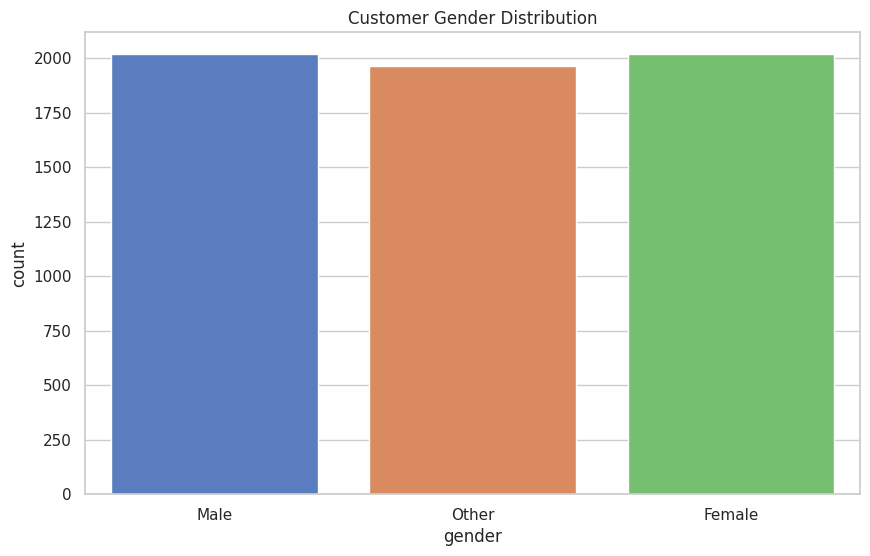

In [13]:
plt.figure()
sns.countplot(x="gender", data=df)
plt.title("Customer Gender Distribution")
plt.show()

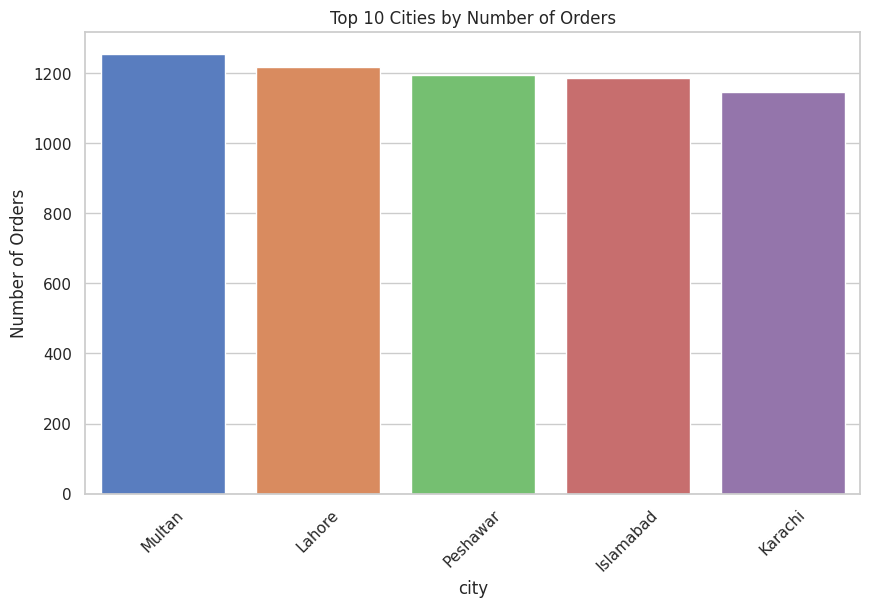

In [14]:
plt.figure()
city_counts = df["city"].value_counts().head(10)
sns.barplot(x=city_counts.index, y=city_counts.values)
plt.title("Top 10 Cities by Number of Orders")
plt.xticks(rotation=45)
plt.ylabel("Number of Orders")
plt.show()

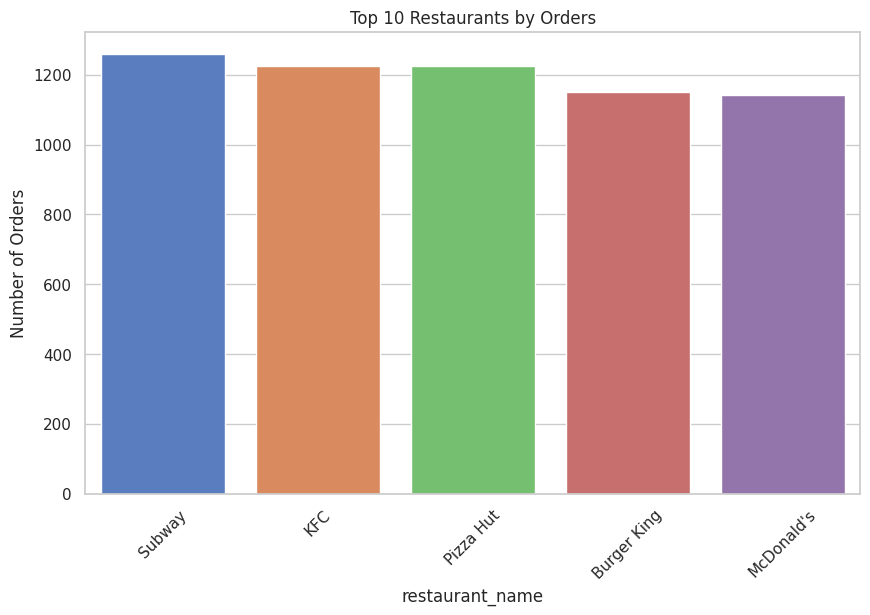

In [15]:
plt.figure()
top_restaurants = df["restaurant_name"].value_counts().head(10)
sns.barplot(x=top_restaurants.index, y=top_restaurants.values)
plt.title("Top 10 Restaurants by Orders")
plt.xticks(rotation=45)
plt.ylabel("Number of Orders")
plt.show()

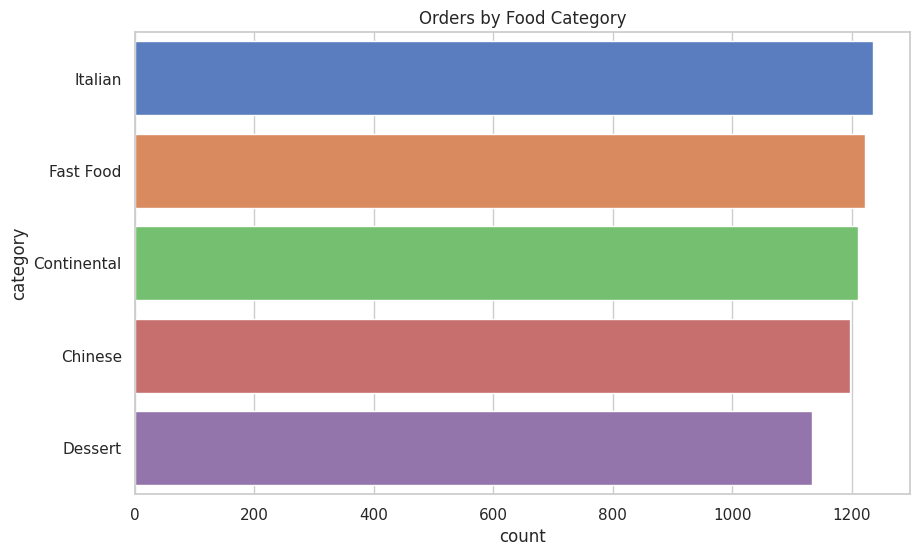

In [16]:
plt.figure()
sns.countplot(y="category", data=df, order=df["category"].value_counts().index)
plt.title("Orders by Food Category")
plt.show()

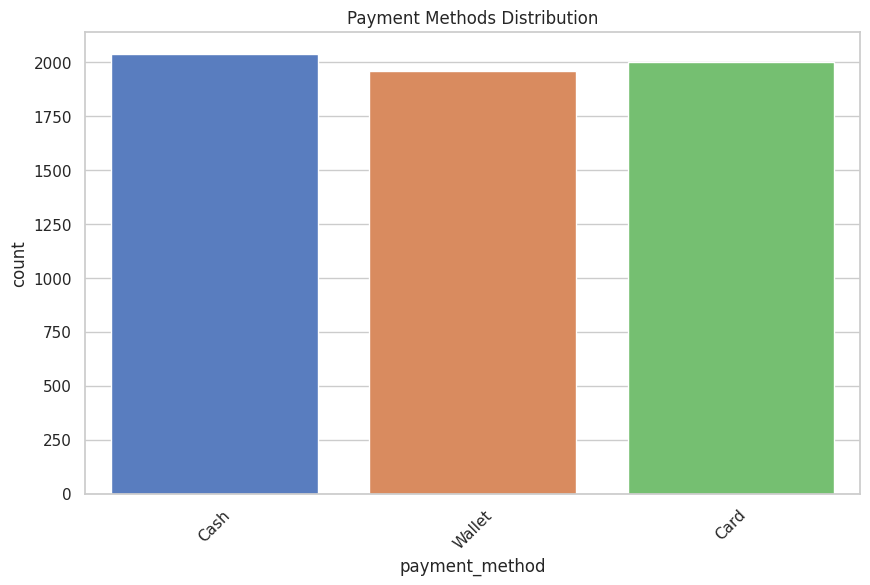

In [17]:
plt.figure()
sns.countplot(x="payment_method", data=df)
plt.title("Payment Methods Distribution")
plt.xticks(rotation=45)
plt.show()

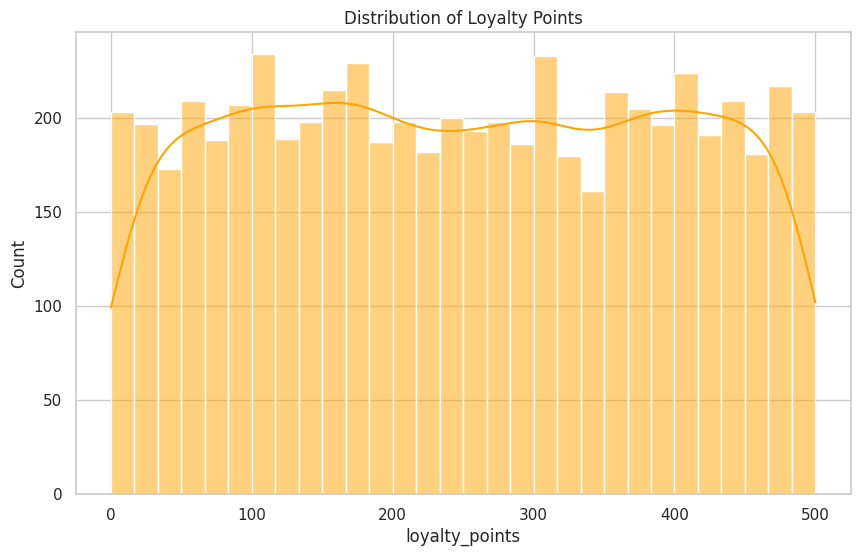

In [18]:
plt.figure()
sns.histplot(df["loyalty_points"], bins=30, kde=True, color="orange")
plt.title("Distribution of Loyalty Points")
plt.show()

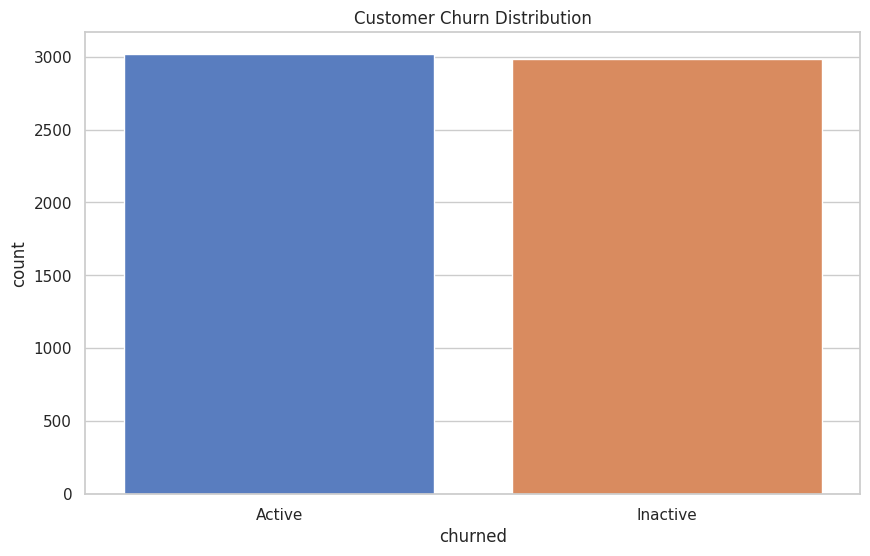

In [19]:
plt.figure()
sns.countplot(x="churned", data=df)
plt.title("Customer Churn Distribution")
plt.show()


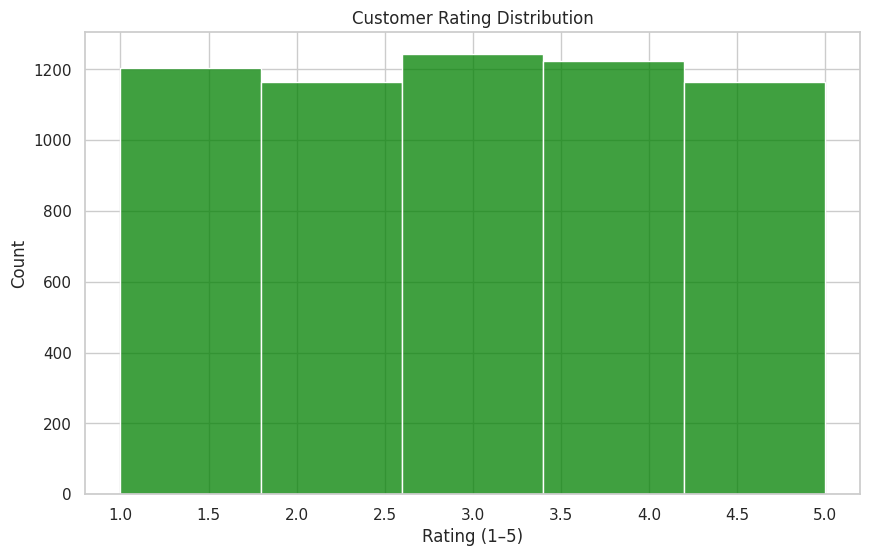

In [20]:
plt.figure()
sns.histplot(df["rating"], bins=5, kde=False, color="green")
plt.title("Customer Rating Distribution")
plt.xlabel("Rating (1–5)")
plt.show()

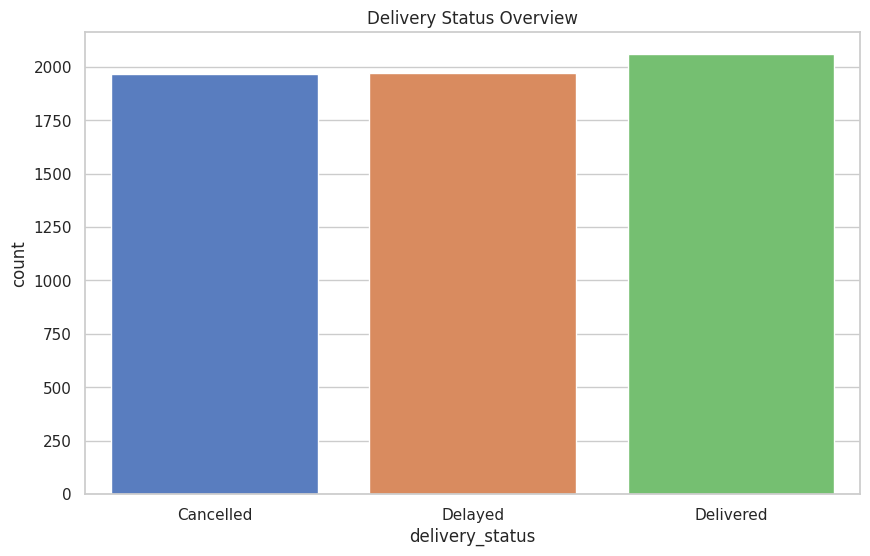

In [21]:
plt.figure()
sns.countplot(x="delivery_status", data=df)
plt.title("Delivery Status Overview")
plt.show()

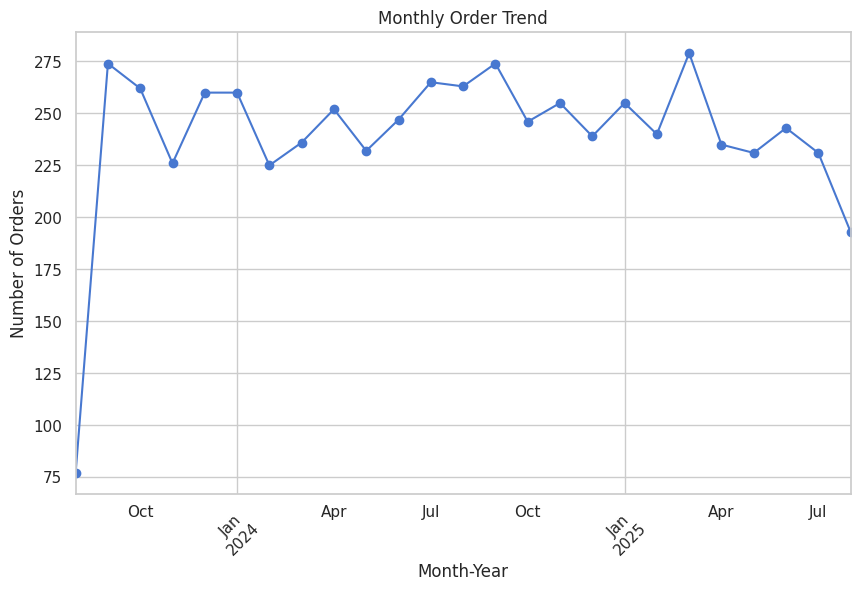

In [22]:
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")
df["month_year"] = df["order_date"].dt.to_period("M")

plt.figure()
monthly_orders = df["month_year"].value_counts().sort_index()
monthly_orders.plot(kind="line", marker="o")
plt.title("Monthly Order Trend")
plt.xlabel("Month-Year")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

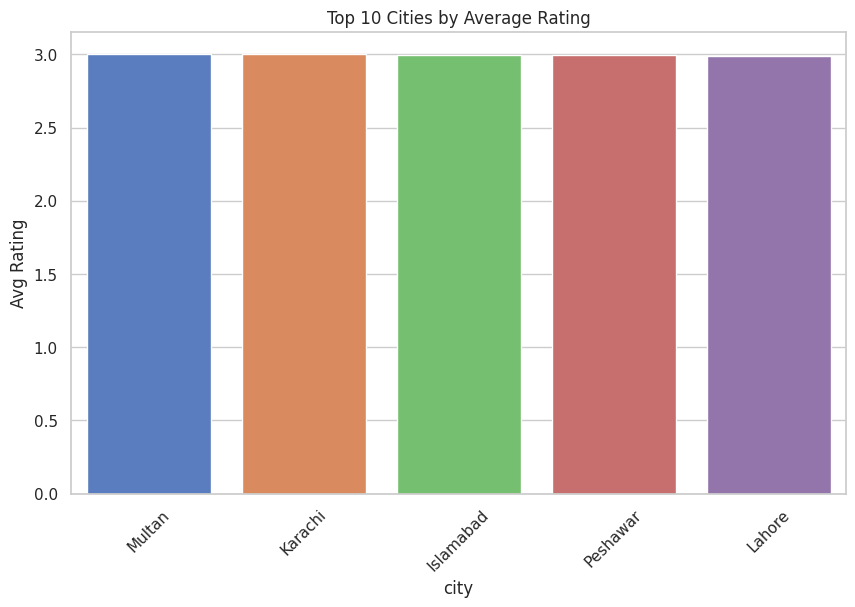

In [23]:
plt.figure()
city_ratings = df.groupby("city")["rating"].mean().sort_values(ascending=False).head(10)
sns.barplot(x=city_ratings.index, y=city_ratings.values)
plt.title("Top 10 Cities by Average Rating")
plt.xticks(rotation=45)
plt.ylabel("Avg Rating")
plt.show()

## Predictive modeling

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

# Copy dataset
model_data = df.copy()

# Map churned column from categorical to binary
if 'churned' in model_data.columns:
    model_data['churned_flag'] = model_data['churned'].map({'Yes': 1, 'No': 0})
else:
    print('Column churned not found in dataset.')

# Drop rows with missing churned_flag
model_data = model_data.dropna(subset=['churned_flag'])

# Select numeric features for prediction
features = ['quantity', 'price', 'order_frequency', 'loyalty_points', 'rating']
model_data = model_data.dropna(subset=features)

# Check if there is enough data
if model_data.shape[0] == 0:
    print('No data available for modeling after preprocessing. Please check data consistency and cleaning steps.')
else:
    X = model_data[features]
    y = model_data['churned_flag']

    # Train-test split
    try:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=42
        )
        if X_train.shape[0] == 0:
            raise ValueError('Training set is empty after splitting. Adjust your preprocessing or test_size parameter.')
    except ValueError as ve:
        print('Error during train_test_split:', ve)
    else:
        # Initialize and train Logistic Regression
        logreg = LogisticRegression(max_iter=1000)
        logreg.fit(X_train, y_train)

        # Predictions & accuracy
        y_pred = logreg.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        print(f'Accuracy of the Logistic Regression model: {accuracy:.2f}')

        # Confusion Matrix Heatmap
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title('Confusion Matrix')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.tight_layout()
        plt.show()

        # ROC Curve
        y_pred_prob = logreg.predict_proba(X_test)[:, 1]
        fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
        roc_auc = auc(fpr, tpr)

        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, label=f'ROC Curve (area = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic (ROC) Curve')
        plt.legend(loc='lower right')
        plt.tight_layout()
        plt.show()


No data available for modeling after preprocessing. Please check data consistency and cleaning steps.


## Thank you...pls upvote!!
